In [ ]:
# metricas para predecir valores numericos(regresion lineal)
    # MSE (MEAN SQUARE ERRROR)-> evalua la funcion de perdida --> valores muy grandes peor se ajusta el modelo (problema de dimensionalidad)
    # coeficiente de determinacion R2 -> mientras mas se acerca a uno es mejor
    # r-ajustada, error maximo, error absoluto promedio (MAE), mediana de los errores absoluto, raiz del promedio de los errores cuadrados (RMSE), varianza explicada

# y = 1 + 0.009X
# y = 1 + 0.009(80)
# y = 1 + 0.72 = 1.72


(np.float64(-0.5), np.float64(647.5), np.float64(463.5), np.float64(-0.5))

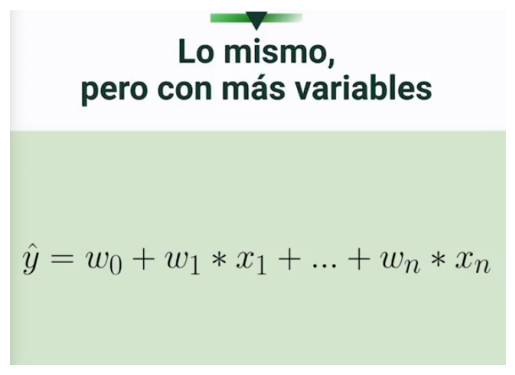

In [13]:
# REGRESION LINEAL MULTIVARIABLE
# Regresion con mas variables 
import matplotlib.pyplot as plt
import matplotlib.image as npimg

img = npimg.imread('../../img/img1.png')
plt.imshow(img)
plt.axis('off')

In [12]:
import pandas as pd
df = pd.read_csv('../../datos/housing.data', header=None, sep='\s+')
df.columns= ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
df.head()

<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_163436/3570220911.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv('../../datos/housing.data', header=None, sep='\s+')


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [10]:
# crear modelo con sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


x = df[['RM', 'INDUS']].values
y = df['MEDV'].values.reshape(-1,1)


sc_x = StandardScaler()
sc_y = StandardScaler()

x_std = sc_x.fit_transform(x)
y_std = sc_y.fit_transform(y)

slr = LinearRegression()
slr.fit(x_std, y_std)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/ml_env/lib64/python3.14/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


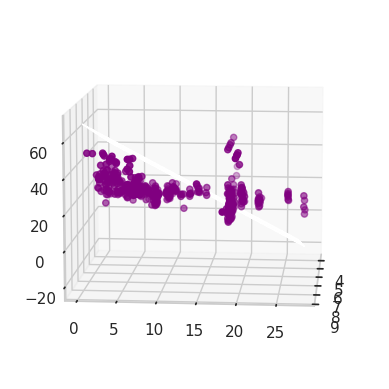

In [ ]:
# plt.scatter(x_std, y_std)
# plt.plot(x_std, slr.predict(x_std), color='Red')
# plt.xlabel('Promedio de los habitantes [RM]')
# plt.ylabel('Precio en 1000 a [MEDV]')
from mpl_toolkits.mplot3d import *
import numpy as np
import matplotlib.pyplot as plt

x1_range = np.arange(df['RM'].min(), df['RM'].max())
x2_range = np.arange(df['INDUS'].min(), df['INDUS'].max())

# crea una malla de valores
x1, x2= np.meshgrid(x1_range, x2_range)
plano = pd.DataFrame({'RM': x1.ravel(), 'INDUS': x2.ravel()})

# prediccion que tenga la misma forma que la malla x1 
pred = slr.predict(plano).reshape(x1.shape)

# inversa transformacion
pred = sc_y.inverse_transform(pred)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1, x2, pred, color='lightblue', alpha=0.4)

ax.scatter3D(df['RM'], df['INDUS'], df['MEDV'], color='purple', marker='o')
# ver desde otro angulo
ax.view_init(elev=10, azim=5)
plt.show()